In [21]:
%reset -f
%load_ext autoreload
%autoreload 2

import glob
from dataclasses import dataclass

import h5py
import numpy as np

import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
channel = "ggF" # ggF, VBF
name = "test" # train, validate, test
dir_list = sorted(glob.glob(f"/root/data/danning_h5/h5_v61/HWW_v6.1/*_{channel}_{name}.h5"))
print(dir_list)

assert len(dir_list) == 1, f"Expected exactly one {channel} {name} file, found {dir_list}"

# Load and concatenate data from the selected files
data = {}
for filepath in dir_list:
    with h5py.File(filepath, mode="r") as file:
        grp = file["atlas"]
        # ``key`` must not shadow the split ``name`` used for the output filename
        file_data = {key: grp[key][()] for key in grp.keys()}

        if not data:
            data = file_data
        else:
            for key in file_data:
                data[key] = np.concatenate([data[key], file_data[key]])

['/root/data/danning_h5/h5_v61/HWW_v6.1/PhPy8_HWW_ggF_test.h5', '/root/data/danning_h5/h5_v61/HWW_v6.1/PhPy8_HWW_VBF_test.h5']


In [23]:
data.keys()

dict_keys(['MET', 'cosThetaW1', 'cosThetaW2', 'eventNumber', 'eventWeight', 'jets', 'leptons', 'luminosity', 'nbjets', 'neutrinos', 'njets', 'phiW1', 'phiW2', 'truth_Ws', 'truth_leptons', 'xsec'])

In [24]:
def px(pt, phi):
    return pt * np.cos(phi)

def py(pt, phi):
    return pt * np.sin(phi)

def pz(pt, eta):
    return pt * np.sinh(eta)

def energy(pt, eta, m):
    return np.sqrt(np.square(pt) + np.square(pz(pt, eta)) + np.square(m))

############################################################################

def pt(px, py):
    return np.sqrt(np.square(px) + np.square(py))

def eta(px, py, pz):
    pt = np.sqrt(np.square(px) + np.square(py))
    return np.arcsinh(np.divide(pz, pt))

def phi(px, py):
    return np.arctan2(py, px)

def m(e, px, py, pz):
    return np.sqrt(np.maximum(0, np.square(e) - np.square(px) - np.square(py) - np.square(pz)))

############################################################################

def dphi_pi(phi1, phi2):
    phi_diff = phi1 - phi2
    phi_diff = np.where(phi_diff < 0.0, -phi_diff, phi_diff)
    phi_diff = np.where(phi_diff > 2.0 * np.pi, phi_diff - 2.0 * np.pi, phi_diff)
    phi_diff = np.where(phi_diff >= np.pi, 2.0 * np.pi - phi_diff, phi_diff)
    return np.divide(phi_diff, np.pi)

In [25]:
# lepton
lep_type = data["leptons"]["type"]
print(np.unique(lep_type[:,0]*lep_type[:,1]))
print(np.sum(lep_type[:,0]*lep_type[:,1] == -(11*13)))
print(np.sum(np.abs(lep_type[:,0]*lep_type[:,1]) == 11*13))


[-169. -143. -121.    0.]
186065
186065


In [26]:
# training features

# lepton
lep_type = data["leptons"]["type"]
print(np.unique(lep_type[:,0]*lep_type[:,1]))
mask = (lep_type[:,0]*lep_type[:,1] == -(11*13)) # df and dc evts only

lep_pt = data["leptons"]["pt"][mask]
lep_eta = data["leptons"]["eta"][mask]
lep_phi = data["leptons"]["phi"][mask]
lep_energy = data["leptons"]["energy"][mask]
lep_charge = data["leptons"]["charge"][mask]
lep_pdgid = data["leptons"]["type"][mask]

lep_pos_pt = np.where(lep_charge[:, 0]>0, lep_pt[:, 0], lep_pt[:, 1])
lep_neg_pt = np.where(lep_charge[:, 0]<0, lep_pt[:, 0], lep_pt[:, 1])
lep_pos_eta = np.where(lep_charge[:, 0]>0, lep_eta[:, 0], lep_eta[:, 1])
lep_neg_eta = np.where(lep_charge[:, 0]<0, lep_eta[:, 0], lep_eta[:, 1])
lep_pos_phi = np.where(lep_charge[:, 0]>0, lep_phi[:, 0], lep_phi[:, 1])
lep_neg_phi = np.where(lep_charge[:, 0]<0, lep_phi[:, 0], lep_phi[:, 1])
lep_pos_pdgid = np.where(lep_charge[:, 0]>0, lep_pdgid[:, 0], lep_pdgid[:, 1])
lep_neg_pdgid = np.where(lep_charge[:, 0]<0, lep_pdgid[:, 0], lep_pdgid[:, 1])

lep_pos_px = px(lep_pos_pt, lep_pos_phi)
lep_pos_py = py(lep_pos_pt, lep_pos_phi)
lep_pos_pz = pz(lep_pos_pt, lep_pos_eta)
lep_pos_energy = np.where(lep_charge[:, 0]>0, lep_energy[:, 0], lep_energy[:, 1])
lep_neg_px = px(lep_neg_pt, lep_neg_phi)
lep_neg_py = py(lep_neg_pt, lep_neg_phi)
lep_neg_pz = pz(lep_neg_pt, lep_neg_eta)
lep_neg_energy = np.where(lep_charge[:, 0]<0, lep_energy[:, 0], lep_energy[:, 1])

# met
met_pt = data["MET"]["MET"][mask]
met_phi = data["MET"]["phi"][mask]

met_px = px(met_pt, met_phi)
met_py = py(met_pt, met_phi)

# jets (10 jets)
jet_pt = data["jets"]["pt"][mask]
jet_eta = data["jets"]["eta"][mask]
jet_phi = data["jets"]["phi"][mask]
jet_btag = data["jets"]["is_tagged"][mask]*1

jet_px = px(jet_pt, jet_phi)
jet_py = py(jet_pt, jet_phi)
jet_pz = pz(jet_pt, jet_eta)
jet_energy = data["jets"]["energy"][mask]

# njets
n_jets = data["njets"][mask]
n_bjets = data["nbjets"][mask]

[-169. -143. -121.    0.]


In [27]:
# target labels

# truth lepton
truth_lep_pt = data["truth_leptons"]["pt"][mask]
truth_lep_eta = data["truth_leptons"]["eta"][mask]
truth_lep_phi = data["truth_leptons"]["phi"][mask]
truth_lep_energy = data["truth_leptons"]["energy"][mask]
truth_lep_charge = data["truth_leptons"]["charge"][mask]
truth_lep_pdgid = data["truth_leptons"]["type"][mask]

truth_lep_pos_pt = np.where(truth_lep_charge[:, 0]>0, truth_lep_pt[:, 0], truth_lep_pt[:, 1])
truth_lep_neg_pt = np.where(truth_lep_charge[:, 0]<0, truth_lep_pt[:, 0], truth_lep_pt[:, 1])
truth_lep_pos_eta = np.where(truth_lep_charge[:, 0]>0, truth_lep_eta[:, 0], truth_lep_eta[:, 1])
truth_lep_neg_eta = np.where(truth_lep_charge[:, 0]<0, truth_lep_eta[:, 0], truth_lep_eta[:, 1])
truth_lep_pos_phi = np.where(truth_lep_charge[:, 0]>0, truth_lep_phi[:, 0], truth_lep_phi[:, 1])
truth_lep_neg_phi = np.where(truth_lep_charge[:, 0]<0, truth_lep_phi[:, 0], truth_lep_phi[:, 1])
truth_lep_pos_pdgid = np.where(truth_lep_charge[:, 0]>0, truth_lep_pdgid[:, 0], truth_lep_pdgid[:, 1])
truth_lep_neg_pdgid = np.where(truth_lep_charge[:, 0]<0, truth_lep_pdgid[:, 0], truth_lep_pdgid[:, 1])

truth_lep_pos_px = px(truth_lep_pos_pt, truth_lep_pos_phi)
truth_lep_pos_py = py(truth_lep_pos_pt, truth_lep_pos_phi)
truth_lep_pos_pz = pz(truth_lep_pos_pt, truth_lep_pos_eta)
truth_lep_pos_energy = np.where(truth_lep_charge[:, 0]>0, truth_lep_energy[:, 0], truth_lep_energy[:, 1])
truth_lep_neg_px = px(truth_lep_neg_pt, truth_lep_neg_phi)
truth_lep_neg_py = py(truth_lep_neg_pt, truth_lep_neg_phi)
truth_lep_neg_pz = pz(truth_lep_neg_pt, truth_lep_neg_eta)
truth_lep_neg_energy = np.where(truth_lep_charge[:, 0]<0, truth_lep_energy[:, 0], truth_lep_energy[:, 1])

# truth w
truth_w_pt = data["truth_Ws"]["pt"][mask]
truth_w_eta = data["truth_Ws"]["eta"][mask]
truth_w_phi = data["truth_Ws"]["phi"][mask]
truth_w_energy = data["truth_Ws"]["energy"][mask]
truth_w_charge = data["truth_Ws"]["charge"][mask]

truth_w_pos_pt = np.where(truth_w_charge[:, 0]>0, truth_w_pt[:, 0], truth_w_pt[:, 1])
truth_w_neg_pt = np.where(truth_w_charge[:, 0]<0, truth_w_pt[:, 0], truth_w_pt[:, 1])
truth_w_pos_eta = np.where(truth_w_charge[:, 0]>0, truth_w_eta[:, 0], truth_w_eta[:, 1])
truth_w_neg_eta = np.where(truth_w_charge[:, 0]<0, truth_w_eta[:, 0], truth_w_eta[:, 1])
truth_w_pos_phi = np.where(truth_w_charge[:, 0]>0, truth_w_phi[:, 0], truth_w_phi[:, 1])
truth_w_neg_phi = np.where(truth_w_charge[:, 0]<0, truth_w_phi[:, 0], truth_w_phi[:, 1])
truth_w_pos_charge = np.where(truth_w_charge[:, 0]>0, truth_w_charge[:, 0], truth_w_charge[:, 1])
truth_w_neg_charge = np.where(truth_w_charge[:, 0]<0, truth_w_charge[:, 0], truth_w_charge[:, 1])

truth_w_pos_px = px(truth_w_pos_pt, truth_w_pos_phi)
truth_w_pos_py = py(truth_w_pos_pt, truth_w_pos_phi)
truth_w_pos_pz = pz(truth_w_pos_pt, truth_w_pos_eta)
truth_w_pos_energy = np.where(truth_w_charge[:, 0]>0, truth_w_energy[:, 0], truth_w_energy[:, 1])
truth_w_pos_mass = np.where(truth_w_charge[:, 0]>0, data["truth_Ws"]["mass"][mask][:,0], data["truth_Ws"]["mass"][mask][:,1])
truth_w_neg_px = px(truth_w_neg_pt, truth_w_neg_phi)
truth_w_neg_py = py(truth_w_neg_pt, truth_w_neg_phi)
truth_w_neg_pz = pz(truth_w_neg_pt, truth_w_neg_eta)
truth_w_neg_energy = np.where(truth_w_charge[:, 0]<0, truth_w_energy[:, 0], truth_w_energy[:, 1])
truth_w_neg_mass = np.where(truth_w_charge[:, 0]<0, data["truth_Ws"]["mass"][mask][:,0], data["truth_Ws"]["mass"][mask][:,1])

# truth nutrinos
truth_nus_pt = data["neutrinos"]["pt"][mask]
truth_nus_eta = data["neutrinos"]["eta"][mask]
truth_nus_phi = data["neutrinos"]["phi"][mask]
truth_nus_energy  = energy(truth_nus_pt, truth_nus_eta, 0)
truth_nus_pdgid = data["neutrinos"]["PDGID"][mask]

truth_nu_pt = np.where(truth_nus_pdgid[:, 0]>0, truth_nus_pt[:, 0], truth_nus_pt[:, 1])
truth_nu_eta = np.where(truth_nus_pdgid[:, 0]>0, truth_nus_eta[:, 0], truth_nus_eta[:, 1])
truth_nu_phi = np.where(truth_nus_pdgid[:, 0]>0, truth_nus_phi[:, 0], truth_nus_phi[:, 1])
truth_nu_pdgid = np.where(truth_nus_pdgid[:, 0]>0, truth_nus_pdgid[:, 0], truth_nus_pdgid[:, 1])
truth_antinu_pt = np.where(truth_nus_pdgid[:, 0]<0, truth_nus_pt[:, 0], truth_nus_pt[:, 1])
truth_antinu_eta = np.where(truth_nus_pdgid[:, 0]<0, truth_nus_eta[:, 0], truth_nus_eta[:, 1])
truth_antinu_phi = np.where(truth_nus_pdgid[:, 0]<0, truth_nus_phi[:, 0], truth_nus_phi[:, 1])
truth_antinu_pdgid = np.where(truth_nus_pdgid[:, 0]<0, truth_nus_pdgid[:, 0], truth_nus_pdgid[:, 1])

truth_nu_px = px(truth_nu_pt, truth_nu_phi)
truth_nu_py = py(truth_nu_pt, truth_nu_phi)
truth_nu_pz = pz(truth_nu_pt, truth_nu_eta)
truth_nu_energy = np.where(truth_nus_pdgid[:, 0]>0, truth_nus_energy[:, 0], truth_nus_energy[:, 1])
truth_antinu_px = px(truth_antinu_pt, truth_antinu_phi)
truth_antinu_py = py(truth_antinu_pt, truth_antinu_phi)
truth_antinu_pz = pz(truth_antinu_pt, truth_antinu_eta)
truth_antinu_energy = np.where(truth_nus_pdgid[:, 0]<0, truth_nus_energy[:, 0], truth_nus_energy[:, 1])

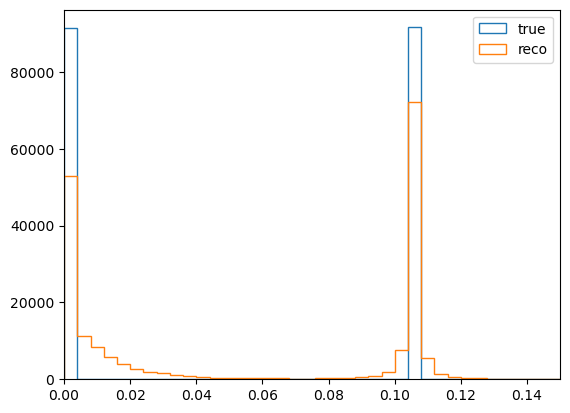

In [28]:
bins_edge = np.linspace(0, 0.2, 51)
plt.hist(m(truth_lep_pos_energy, truth_lep_pos_px, truth_lep_pos_py, truth_lep_pos_pz), bins=bins_edge, histtype="step", label="true")
plt.hist(m(lep_pos_energy, lep_pos_px, lep_pos_py, lep_pos_pz), bins=bins_edge, histtype="step", label="reco")
plt.legend()
plt.xlim(0, 0.15)
plt.show()

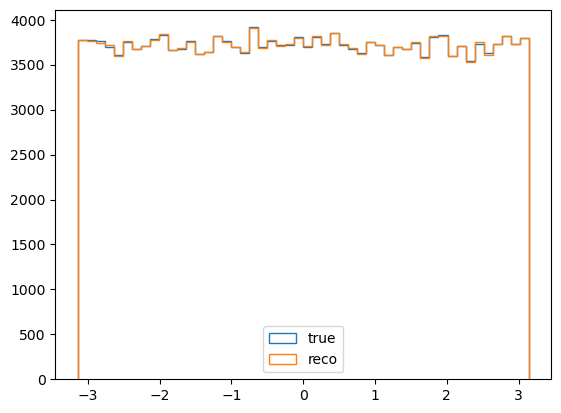

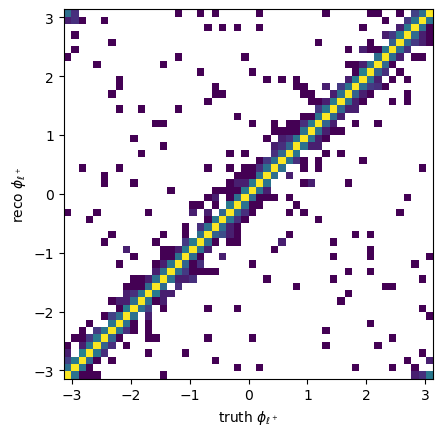

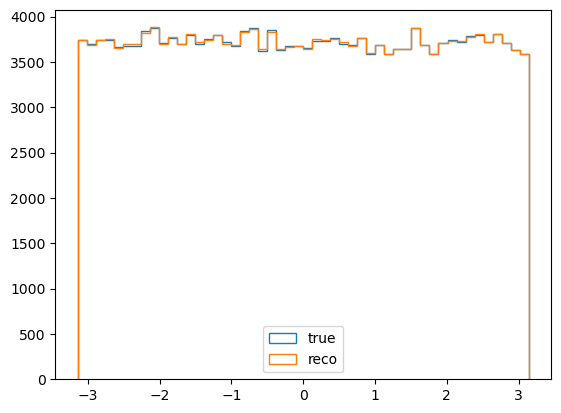

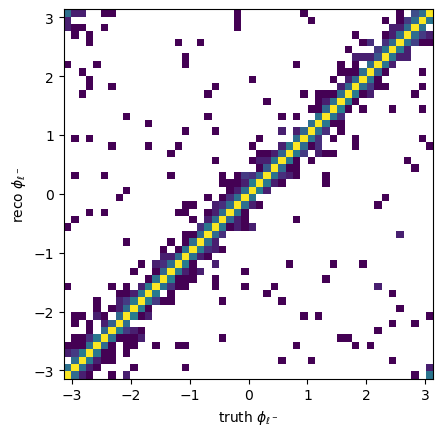

In [29]:
bins_edge = np.linspace(-np.pi, np.pi, 51)
plt.hist(truth_lep_pos_phi, bins=bins_edge, histtype="step", label="true")
plt.hist(lep_pos_phi, bins=bins_edge, histtype="step", label="reco")
# plt.xlim(0, 0.15)
plt.legend()
plt.show()

from matplotlib.colors import LogNorm
norm = LogNorm(vmin=1)
plt.hist2d(truth_lep_pos_phi, lep_pos_phi, bins=[bins_edge, bins_edge], cmap="viridis", norm=norm)
plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
plt.xlabel(r"truth $\phi_{\ell^+}$")
plt.ylabel(r"reco $\phi_{\ell^+}$")
plt.show()

plt.hist(truth_lep_neg_phi, bins=bins_edge, histtype="step", label="true")
plt.hist(lep_neg_phi, bins=bins_edge, histtype="step", label="reco")
# plt.xlim(0, 0.15)
plt.legend()
plt.show()

norm = LogNorm(vmin=1)
plt.hist2d(truth_lep_neg_phi, lep_neg_phi, bins=[bins_edge, bins_edge], cmap="viridis", norm=norm)
plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
plt.xlabel(r"truth $\phi_{\ell^-}$")
plt.ylabel(r"reco $\phi_{\ell^-}$")
plt.show()

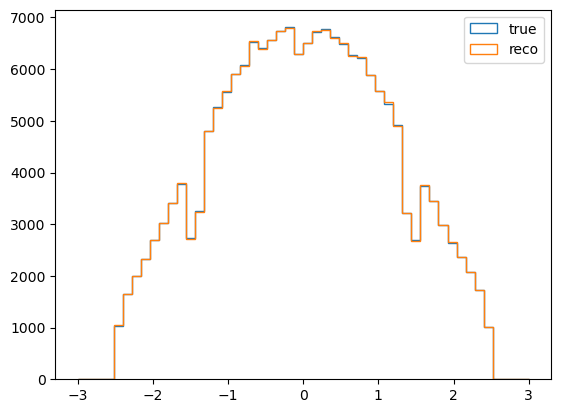

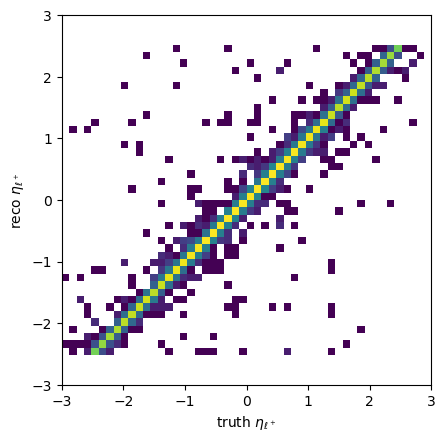

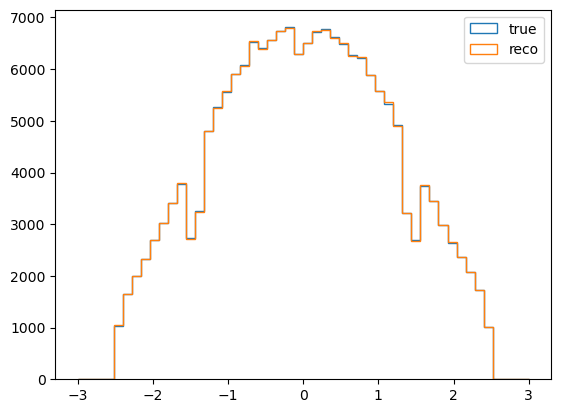

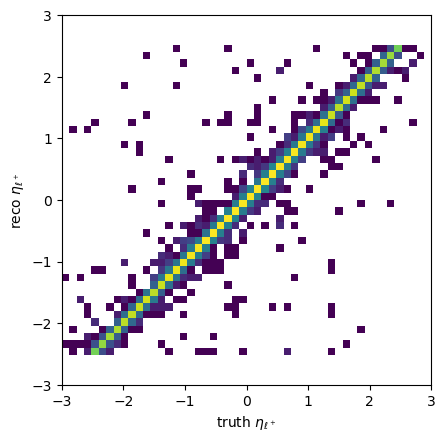

In [30]:
bins_edge = np.linspace(-3, 3, 51)
plt.hist(truth_lep_pos_eta, bins=bins_edge, histtype="step", label="true")
plt.hist(lep_pos_eta, bins=bins_edge, histtype="step", label="reco")
plt.legend()
# plt.xlim(0, 0.15)
plt.show()

norm = LogNorm(vmin=1)
plt.hist2d(truth_lep_pos_eta, lep_pos_eta, bins=[bins_edge, bins_edge], cmap="viridis", norm=norm)
plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
plt.xlabel(r"truth $\eta_{\ell^+}$")
plt.ylabel(r"reco $\eta_{\ell^+}$")
plt.show()

plt.hist(truth_lep_pos_eta, bins=bins_edge, histtype="step", label="true")
plt.hist(lep_pos_eta, bins=bins_edge, histtype="step", label="reco")
plt.legend()
# plt.xlim(0, 0.15)
plt.show()

norm = LogNorm(vmin=1)
plt.hist2d(truth_lep_pos_eta, lep_pos_eta, bins=[bins_edge, bins_edge], cmap="viridis", norm=norm)
plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
plt.xlabel(r"truth $\eta_{\ell^+}$")
plt.ylabel(r"reco $\eta_{\ell^+}$")
plt.show()

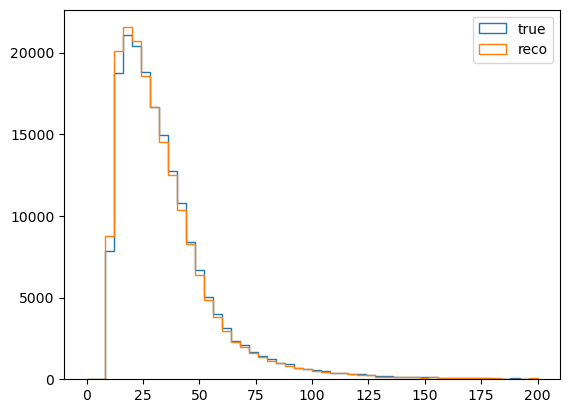

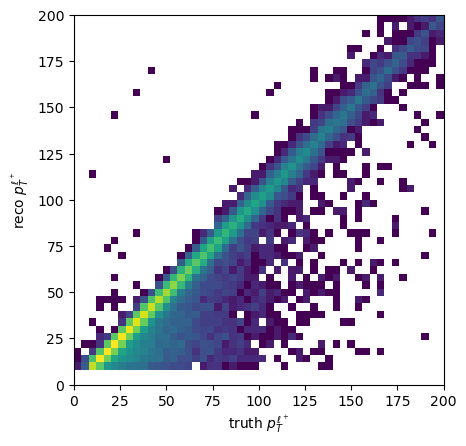

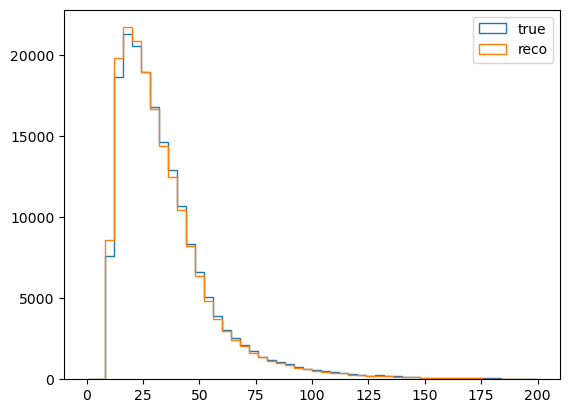

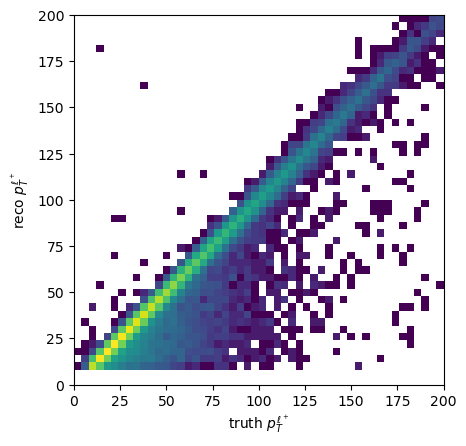

In [31]:
bins_edge = np.linspace(0, 200, 51)
plt.hist(truth_lep_pos_pt, bins=bins_edge, histtype="step",label="true")
plt.hist(lep_pos_pt, bins=bins_edge, histtype="step", label="reco")
# plt.xlim(0, 0.15)
plt.legend()
plt.show()

norm = LogNorm(vmin=1)
plt.hist2d(truth_lep_pos_pt, lep_pos_pt, bins=[bins_edge, bins_edge], cmap="viridis", norm=norm)
plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
plt.xlabel(r"truth $p_{T}^{\ell^+}$")
plt.ylabel(r"reco $p_{T}^{\ell^+}$")
plt.show()

bins_edge = np.linspace(0, 200, 51)
plt.hist(truth_lep_neg_pt, bins=bins_edge, histtype="step", label="true")
plt.hist(lep_neg_pt, bins=bins_edge, histtype="step", label="reco")
# plt.xlim(0, 0.15)
plt.legend()
plt.show()

norm = LogNorm(vmin=1)
plt.hist2d(truth_lep_neg_pt, lep_neg_pt, bins=[bins_edge, bins_edge], cmap="viridis", norm=norm)
plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
plt.xlabel(r"truth $p_{T}^{\ell^+}$")
plt.ylabel(r"reco $p_{T}^{\ell^+}$")
plt.show()

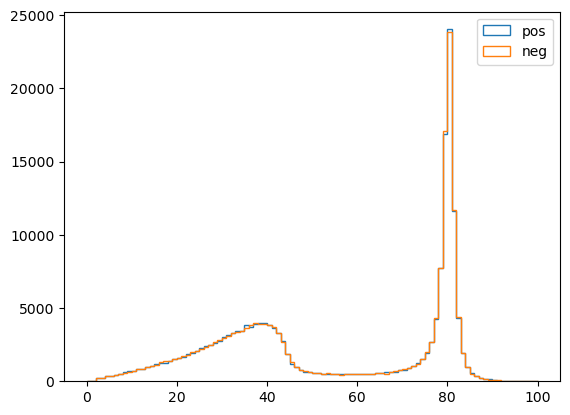

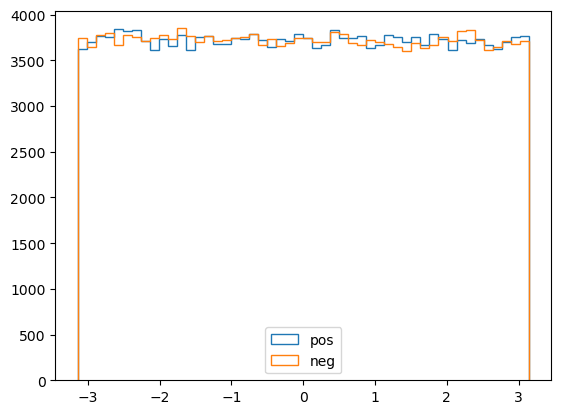

In [32]:
# sanity check (random checks)
assert truth_w_pos_py.shape[0] == lep_neg_px.shape[0]
assert truth_w_neg_energy.shape[0] == lep_pos_pz.shape[0]

w_pos_mass = m(truth_w_pos_energy, truth_w_pos_px, truth_w_pos_py, truth_w_pos_pz)
w_neg_mass = m(truth_w_neg_energy, truth_w_neg_px, truth_w_neg_py, truth_w_neg_pz)
bins_edge = np.linspace(0, 100, 101)
plt.hist(w_pos_mass, bins=bins_edge, histtype="step", label="pos")
plt.hist(w_neg_mass, bins=bins_edge, histtype="step", label="neg")
plt.legend()
plt.show()

bins_edge = np.linspace(-np.pi, np.pi, 51)
plt.hist(truth_w_pos_phi, bins=bins_edge, histtype="step", label="pos")
plt.hist(truth_w_neg_phi, bins=bins_edge, histtype="step", label="neg")
plt.legend()
plt.show()

In [33]:
# truth particles dataclass

@dataclass
class Truth_pos_lep:
    px = truth_lep_pos_px
    py = truth_lep_pos_py
    pz = truth_lep_pos_pz
    energy = truth_lep_pos_energy
    pt = truth_lep_pos_pt
    eta = truth_lep_pos_eta
    phi = truth_lep_pos_phi
    p4 = np.stack([px, py, pz, energy], axis=-1)
    p3 = np.stack([px, py, pz], axis=-1)
    pdgId = truth_lep_pos_pdgid

@dataclass
class Truth_neg_lep:
    px = truth_lep_neg_px
    py = truth_lep_neg_py
    pz = truth_lep_neg_pz
    energy = truth_lep_neg_energy
    pt = truth_lep_neg_pt
    eta = truth_lep_neg_eta
    phi = truth_lep_neg_phi
    p4 = np.stack([px, py, pz, energy], axis=-1)
    p3 = np.stack([px, py, pz], axis=-1)
    pdgId = truth_lep_neg_pdgid

@dataclass
class Truth_nu:
    px = truth_nu_px
    py = truth_nu_py
    pz = truth_nu_pz
    energy = truth_nu_energy
    pt = truth_nu_pt
    eta = truth_nu_eta
    phi = truth_nu_phi
    p4 = np.stack([px, py, pz, energy], axis=-1)
    p3 = np.stack([px, py, pz], axis=-1)
    pdgId = truth_nu_pdgid

@dataclass
class Truth_antinu:
    px = truth_antinu_px
    py = truth_antinu_py
    pz = truth_antinu_pz
    energy = truth_antinu_energy
    pt = truth_antinu_pt
    eta = truth_antinu_eta
    phi = truth_antinu_phi
    p4 = np.stack([px, py, pz, energy], axis=-1)
    p3 = np.stack([px, py, pz], axis=-1)
    pdgId = truth_antinu_pdgid

@dataclass
class Truth_pos_w:
    px = truth_w_pos_px
    py = truth_w_pos_py
    pz = truth_w_pos_pz
    energy = truth_w_pos_energy
    pt = truth_w_pos_pt
    eta = truth_w_pos_eta
    phi = truth_w_pos_phi
    m = truth_w_pos_mass
    p4 = np.stack([px, py, pz, energy], axis=-1)
    p3 = np.stack([px, py, pz], axis=-1)
    charge = truth_w_pos_charge

@dataclass
class Truth_neg_w:
    px = truth_w_neg_px
    py = truth_w_neg_py
    pz = truth_w_neg_pz
    energy = truth_w_neg_energy
    pt = truth_w_neg_pt
    eta = truth_w_neg_eta
    phi = truth_w_neg_phi
    m = truth_w_neg_mass
    p4 = np.stack([px, py, pz, energy], axis=-1)
    p3 = np.stack([px, py, pz], axis=-1)
    charge = truth_w_neg_charge

# reco particles dataclass

@dataclass
class Pos_lep:
    px = lep_pos_px
    py = lep_pos_py
    pz = lep_pos_pz
    energy = lep_pos_energy
    pt = lep_pos_pt
    eta = lep_pos_eta
    phi = lep_pos_phi
    p4 = np.stack([px, py, pz, energy], axis=-1)
    p3 = np.stack([px, py, pz], axis=-1)
    pdgId = lep_pos_pdgid

@dataclass
class Neg_lep:
    px = lep_neg_px
    py = lep_neg_py
    pz = lep_neg_pz
    energy = lep_neg_energy
    pt = lep_neg_pt
    eta = lep_neg_eta
    phi = lep_neg_phi
    p4 = np.stack([px, py, pz, energy], axis=-1)
    p3 = np.stack([px, py, pz], axis=-1)
    pdgId = lep_neg_pdgid
    
@dataclass
class Met:
    px = met_px
    py = met_py
    pt = met_pt
    phi = met_phi
    
@dataclass
class Jets:
    px = jet_px
    py = jet_py
    pz = jet_pz
    energy = jet_energy
    pt = jet_pt
    eta = jet_eta
    phi = jet_phi
    btag = jet_btag
    p4 = np.stack([px, py, pz, energy], axis=-1)
    p3 = np.stack([px, py, pz], axis=-1)
    n_jets = n_jets
    n_bjets = n_bjets
    
@dataclass
class Event:
    eventNumber = data["eventNumber"][mask]
    eventWeight = data["eventWeight"][mask]

In [34]:
def save_dataclasses_to_h5(filename, **dataclasses_dict):
    """
    Save dataclasses to an HDF5 file
    
    Args:
        filename: Path to the output HDF5 file
        **dataclasses_dict: Keyword arguments with names and dataclass instances
    """
    with h5py.File(filename, 'w') as f:
        # For each dataclass
        for group_name, dataclass_instance in dataclasses_dict.items():
            # Create a group for this dataclass
            group = f.create_group(group_name)
            
            # Get all attributes that aren't special methods
            for attr_name in dir(dataclass_instance):
                if not attr_name.startswith('_'):  # Skip private attributes
                    try:
                        attr_value = getattr(dataclass_instance, attr_name)
                        # Handle numpy arrays
                        if isinstance(attr_value, np.ndarray):
                            group.create_dataset(attr_name, data=attr_value, compression="gzip")
                        # Handle scalars
                        elif np.isscalar(attr_value):
                            group.attrs[attr_name] = attr_value
                    except Exception as e:
                        raise RuntimeError(f"Error saving {group_name}.{attr_name}") from e

    
save_file_name = f"/root/data/danning_h5/ypeng/mc20_qe_v61_recotruth_{channel}_{name}.h5"
save_dataclasses_to_h5(
    save_file_name,
    truth_pos_lep=Truth_pos_lep(),
    truth_neg_lep=Truth_neg_lep(),
    truth_nu=Truth_nu(),
    truth_antinu=Truth_antinu(),
    truth_pos_w=Truth_pos_w(),
    truth_neg_w=Truth_neg_w(),
    pos_lep=Pos_lep(),
    neg_lep=Neg_lep(),
    met=Met(),
    jets=Jets(),
    event=Event()
)
print(f"Successfully saved particle data to {save_file_name}")

Successfully saved particle data to /root/data/danning_h5/ypeng/mc20_qe_v61_recotruth_ggF_test.h5


In [35]:
def load_particles_from_h5(filename=f"/root/data/danning_h5/ypeng/mc20_qe_v61_recotruth_{channel}_{name}.h5"):
    """
    Load particle data from an HDF5 file
    
    Args:
        filename: Path to the HDF5 file
        
    Returns:
        Dictionary with the loaded data
    """
    result = {}
    
    with h5py.File(filename, 'r') as f:
        # For each group in the file
        for group_name in f.keys():
            group_data = {}
            
            # Load datasets (numpy arrays)
            for dataset_name in f[group_name].keys():
                group_data[dataset_name] = f[group_name][dataset_name][:]
            
            # Load attributes (scalars)
            for attr_name, attr_value in f[group_name].attrs.items():
                group_data[attr_name] = attr_value
            
            result[group_name] = group_data
            
    return result

In [36]:
saved = load_particles_from_h5()

In [37]:
# truth leptons
truth_lep_pos_px = saved["truth_pos_lep"]["px"]
truth_lep_pos_py = saved["truth_pos_lep"]["py"]
truth_lep_pos_pz = saved["truth_pos_lep"]["pz"]
truth_lep_pos_energy = saved["truth_pos_lep"]["energy"]
truth_lep_neg_px = saved["truth_neg_lep"]["px"]
truth_lep_neg_py = saved["truth_neg_lep"]["py"]
truth_lep_neg_pz = saved["truth_neg_lep"]["pz"]
truth_lep_neg_energy = saved["truth_neg_lep"]["energy"]

# training features
lep_pos_px = saved["pos_lep"]["px"]
lep_pos_py = saved["pos_lep"]["py"]
lep_pos_pz = saved["pos_lep"]["pz"]
lep_pos_energy = saved["pos_lep"]["energy"]
lep_neg_px = saved["neg_lep"]["px"]
lep_neg_py = saved["neg_lep"]["py"]
lep_neg_pz = saved["neg_lep"]["pz"]
lep_neg_energy = saved["neg_lep"]["energy"]

met_px = saved["met"]["px"]
met_py = saved["met"]["py"]

jet_px = saved["jets"]["px"]
jet_py = saved["jets"]["py"]
jet_pz = saved["jets"]["pz"]
jet_energy = saved["jets"]["energy"]
jet_pt = saved["jets"]["pt"]
jet_btag = saved["jets"]["btag"]
n_jets = saved["jets"]["n_jets"]
n_bjets = saved["jets"]["n_bjets"]

eventNumber = saved["event"]["eventNumber"]
eventWeight = saved["event"]["eventWeight"]

def col(a):
    return a.reshape(a.shape[0], -1)

inputs = np.concat([
    col(lep_pos_px),
    col(lep_pos_py),
    col(lep_pos_pz),
    col(lep_pos_energy),
    col(lep_neg_px),
    col(lep_neg_py),
    col(lep_neg_pz),
    col(lep_neg_energy),
    col(met_px),
    col(met_py),
    col(jet_px),
    col(jet_py),
    col(jet_pz),
    col(jet_energy),
    col(jet_pt),
    col(jet_btag),
    col(n_jets),
    col(n_bjets),
], axis=-1)

print("inputs.shape =", inputs.shape)

# training labels
labels = np.concatenate([
    col(saved["truth_pos_w"]["px"]),
    col(saved["truth_pos_w"]["py"]),
    col(saved["truth_pos_w"]["pz"]),
    col(saved["truth_pos_w"]["energy"]),
    col(saved["truth_neg_w"]["px"]),
    col(saved["truth_neg_w"]["py"]),
    col(saved["truth_neg_w"]["pz"]),
    col(saved["truth_neg_w"]["energy"]),
], axis=-1)

print("labels.shape =", labels.shape)

inputs.shape = (186065, 72)
labels.shape = (186065, 8)


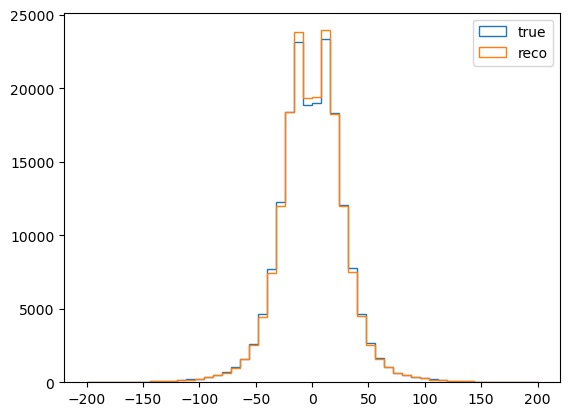

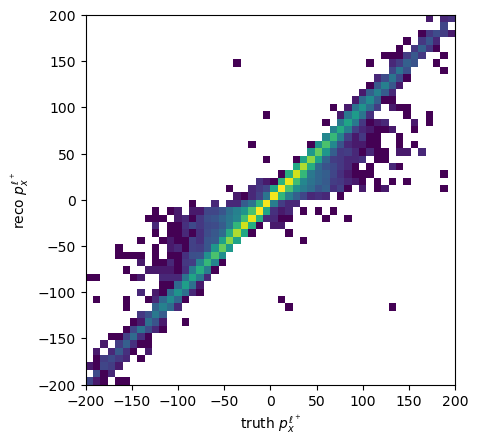

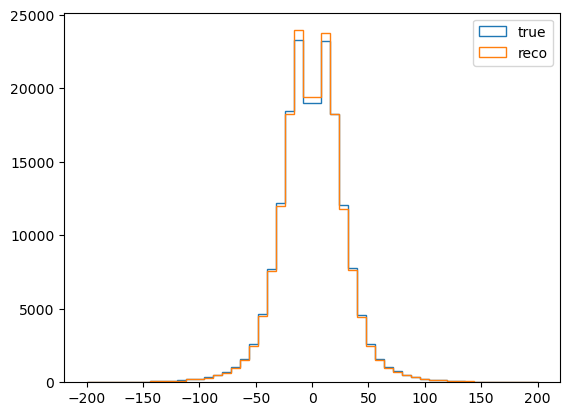

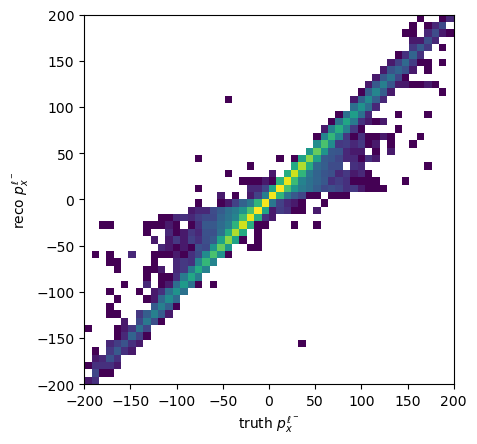

In [38]:
bins_edge = np.linspace(-200, 200, 51)
plt.hist(truth_lep_pos_px, bins=bins_edge, histtype="step", label="true")
plt.hist(lep_pos_px, bins=bins_edge, histtype="step", label="reco")
# plt.xlim(0, 0.15)
plt.legend()
plt.show()

norm = LogNorm(vmin=1)
plt.hist2d(truth_lep_pos_px, lep_pos_px, bins=[bins_edge, bins_edge], cmap="viridis", norm=norm)
plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
plt.xlabel(r"truth $p_{x}^{\ell^+}$")
plt.ylabel(r"reco $p_{x}^{\ell^+}$")
plt.show()

plt.hist(truth_lep_neg_px, bins=bins_edge, histtype="step", label="true")
plt.hist(lep_neg_px, bins=bins_edge, histtype="step", label="reco")
# plt.xlim(0, 0.15)
plt.legend()
plt.show()

norm = LogNorm(vmin=1)
plt.hist2d(truth_lep_neg_px, lep_neg_px, bins=[bins_edge, bins_edge], cmap="viridis", norm=norm)
plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
plt.xlabel(r"truth $p_{x}^{\ell^-}$")
plt.ylabel(r"reco $p_{x}^{\ell^-}$")
plt.show()

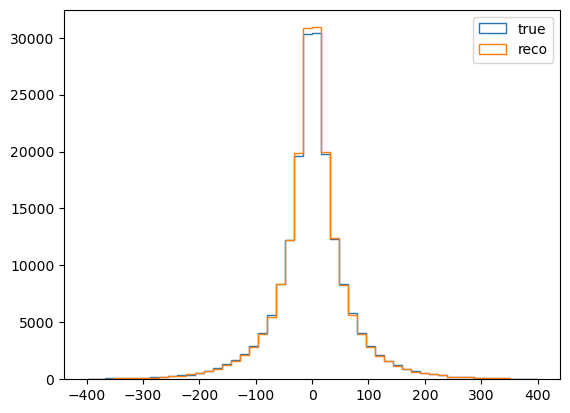

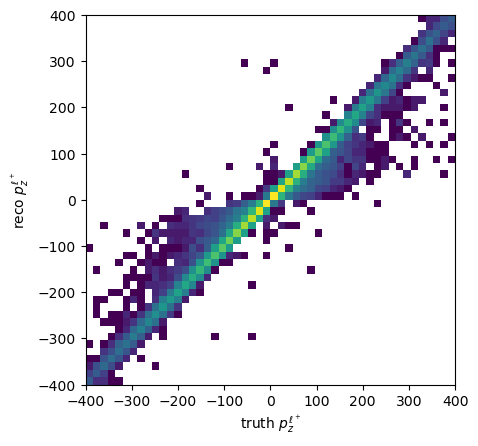

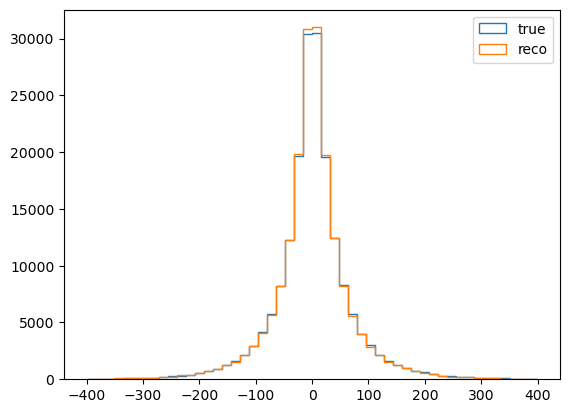

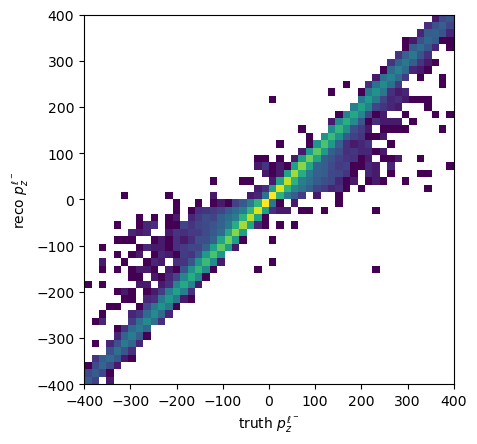

In [39]:
bins_edge = np.linspace(-400, 400, 51)
plt.hist(truth_lep_pos_pz, bins=bins_edge, histtype="step", label="true")
plt.hist(lep_pos_pz, bins=bins_edge, histtype="step", label="reco")
# plt.xlim(0, 0.15)
plt.legend()
plt.show()

norm = LogNorm(vmin=1)
plt.hist2d(truth_lep_pos_pz, lep_pos_pz, bins=[bins_edge, bins_edge], cmap="viridis", norm=norm)
plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
plt.xlabel(r"truth $p_{z}^{\ell^+}$")
plt.ylabel(r"reco $p_{z}^{\ell^+}$")
plt.show()

plt.hist(truth_lep_neg_pz, bins=bins_edge, histtype="step", label="true")
plt.hist(lep_neg_pz, bins=bins_edge, histtype="step", label="reco")
# plt.xlim(0, 0.15)
plt.legend()
plt.show()

norm = LogNorm(vmin=1)
plt.hist2d(truth_lep_neg_pz, lep_neg_pz, bins=[bins_edge, bins_edge], cmap="viridis", norm=norm)
plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
plt.xlabel(r"truth $p_{z}^{\ell^-}$")
plt.ylabel(r"reco $p_{z}^{\ell^-}$")
plt.show()

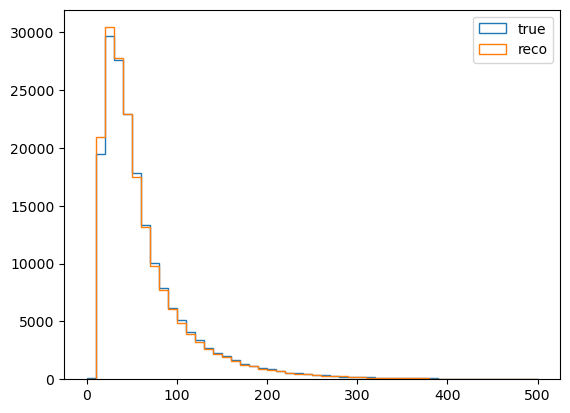

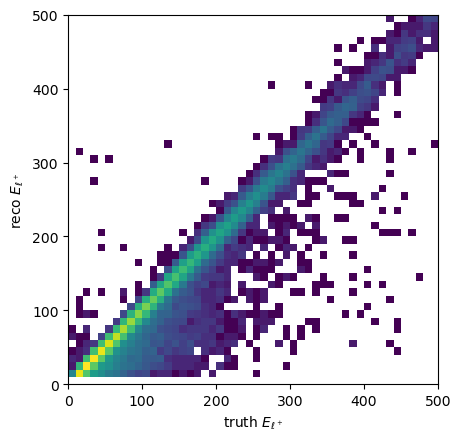

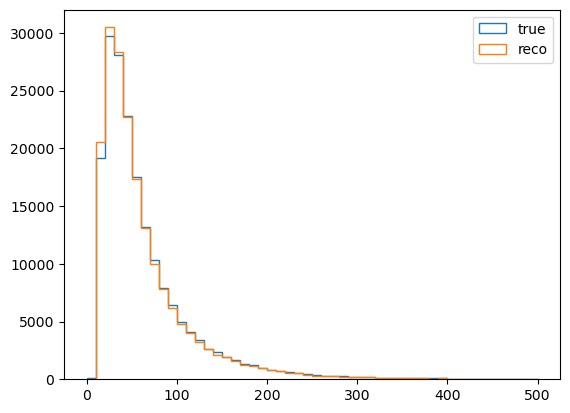

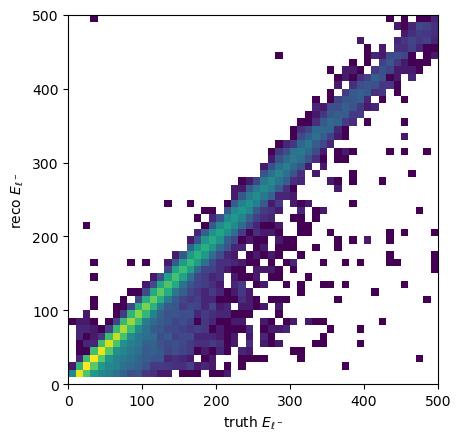

In [40]:
bins_edge = np.linspace(0, 500, 51)
plt.hist(truth_lep_pos_energy, bins=bins_edge, histtype="step", label="true")
plt.hist(lep_pos_energy, bins=bins_edge, histtype="step", label="reco")
# plt.xlim(0, 0.15)
plt.legend()
plt.show()

norm = LogNorm(vmin=1)
plt.hist2d(truth_lep_pos_energy, lep_pos_energy, bins=[bins_edge, bins_edge], cmap="viridis", norm=norm)
plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
plt.xlabel(r"truth $E_{\ell^+}$")
plt.ylabel(r"reco $E_{\ell^+}$")
plt.show()

plt.hist(truth_lep_neg_energy, bins=bins_edge, histtype="step", label="true")
plt.hist(lep_neg_energy, bins=bins_edge, histtype="step", label="reco")
# plt.xlim(0, 0.15)
plt.legend()
plt.show()

norm = LogNorm(vmin=1)
plt.hist2d(truth_lep_neg_energy, lep_neg_energy, bins=[bins_edge, bins_edge], cmap="viridis", norm=norm)
plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
plt.xlabel(r"truth $E_{\ell^-}$")
plt.ylabel(r"reco $E_{\ell^-}$")
plt.show()